1 Execute Next Step

In [1]:
pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import gc
import time
import math
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

try:
    import polars as pl
    HAS_POLARS = True
except Exception:
    HAS_POLARS = False

try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except Exception:
    HAS_RAPIDFUZZ = False

print("🚀 [ML Navigators] Environment ready")
print("Polars:", HAS_POLARS)
print("RapidFuzz:", HAS_RAPIDFUZZ)

🚀 [ML Navigators] Environment ready
Polars: False
RapidFuzz: True


2 Execute Next Step

In [3]:
import os
from pathlib import Path

DATA_ROOT = Path(os.path.expanduser("~/student_resource/dataset"))

print("\nSelected DATA_ROOT:", DATA_ROOT)

all_files = sorted(DATA_ROOT.rglob("*"))
for f in all_files:
    if f.is_file():
        print(" -", f.relative_to(DATA_ROOT))


Selected DATA_ROOT: /home/sagemaker-user/student_resource/dataset
 - test/test_source1.tsv
 - test/test_source2.tsv
 - test/test_source3.tsv
 - test/test_source_1.xlsx
 - train/train_ground_truth.tsv
 - train/train_source1.tsv
 - train/train_source2.tsv
 - train/train_source3.tsv


3 Execute Next Step

In [4]:
def find_file(filename):
    hits = list(DATA_ROOT.rglob(filename))
    if not hits:
        raise FileNotFoundError(f"Could not find {filename}")
    return hits[0]

FILES = {
    "train_s1": find_file("train_source1.tsv"),
    "train_s2": find_file("train_source2.tsv"),
    "train_s3": find_file("train_source3.tsv"),
    "ground_truth": find_file("train_ground_truth.tsv"),
    "test_s1": find_file("test_source1.tsv"),
    "test_s2": find_file("test_source2.tsv"),
    "test_s3": find_file("test_source3.tsv"),
}

for k, v in FILES.items():
    print(f"🚀 [ML Navigators] {k:14s} -> {v}")

🚀 [ML Navigators] train_s1       -> /home/sagemaker-user/student_resource/dataset/train/train_source1.tsv
🚀 [ML Navigators] train_s2       -> /home/sagemaker-user/student_resource/dataset/train/train_source2.tsv
🚀 [ML Navigators] train_s3       -> /home/sagemaker-user/student_resource/dataset/train/train_source3.tsv
🚀 [ML Navigators] ground_truth   -> /home/sagemaker-user/student_resource/dataset/train/train_ground_truth.tsv
🚀 [ML Navigators] test_s1        -> /home/sagemaker-user/student_resource/dataset/test/test_source1.tsv
🚀 [ML Navigators] test_s2        -> /home/sagemaker-user/student_resource/dataset/test/test_source2.tsv
🚀 [ML Navigators] test_s3        -> /home/sagemaker-user/student_resource/dataset/test/test_source3.tsv


4 Execute Next Step

In [5]:
for k, path in FILES.items():
    size_mb = path.stat().st_size / (1024**2)
    print(f"🚀 [ML Navigators] {k:14s} {size_mb:10.1f} MB")

def preview_tsv(path, n=5):
    return pd.read_csv(path, sep="\t", nrows=n)

print("🚀 [ML Navigators] \nTRAIN SOURCE 1 PREVIEW")
display(preview_tsv(FILES["train_s1"]))

print("🚀 [ML Navigators] \nGROUND TRUTH PREVIEW")
display(preview_tsv(FILES["ground_truth"]))

🚀 [ML Navigators] train_s1            200.3 MB
🚀 [ML Navigators] train_s2            466.6 MB
🚀 [ML Navigators] train_s3            480.4 MB
🚀 [ML Navigators] ground_truth        121.1 MB
🚀 [ML Navigators] test_s1             166.9 MB
🚀 [ML Navigators] test_s2             485.9 MB
🚀 [ML Navigators] test_s3             482.6 MB
🚀 [ML Navigators] 
TRAIN SOURCE 1 PREVIEW


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


🚀 [ML Navigators] 
GROUND TRUTH PREVIEW


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


5 Execute Next Step

In [6]:
CORE_COLS = ["entity_id", "business_name", "business_address", "country"]

for name in ["train_s1", "train_s2", "train_s3", "test_s1", "test_s2", "test_s3"]:
    df = pd.read_csv(FILES[name], sep="\t", nrows=3)
    print(f"🚀 [ML Navigators] \n{name}")
    print(df.dtypes)
    print("columns:", list(df.columns))

🚀 [ML Navigators] 
train_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']
🚀 [ML Navigators] 
train_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']
🚀 [ML Navigators] 
train_s3
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']
🚀 [ML Navigators] 
test_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']
🚀 [ML Navigators] 
test_s2
entity_id           object
business_name       object
business_address    object
country  

6 Execute Next Step

In [7]:
SAMPLE_N = 50_000
RANDOM_STATE = 42

def sample_tsv(path, n=SAMPLE_N, seed=RANDOM_STATE):
    return pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        nrows=n
    )

eda_s1 = sample_tsv(FILES["train_s1"])
eda_s2 = sample_tsv(FILES["train_s2"])
eda_s3 = sample_tsv(FILES["train_s3"])

for label, df in [("S1", eda_s1), ("S2", eda_s2), ("S3", eda_s3)]:
    print(f"🚀 [ML Navigators] \n===== {label} =====")
    print("rows:", len(df))
    print("🚀 [ML Navigators] missing:")
    display(df.isna().mean().mul(100).round(2).to_frame("missing_%"))
    print("🚀 [ML Navigators] countries:")
    display(df["country"].value_counts(dropna=False).head(15).to_frame("count"))

🚀 [ML Navigators] 
===== S1 =====
rows: 50000
🚀 [ML Navigators] missing:


,missing_%
entity_id,0.0
business_name,0.0
business_address,0.0
country,0.0


🚀 [ML Navigators] countries:


,count
country,
US,29965
India,20035


🚀 [ML Navigators] 
===== S2 =====
rows: 50000
🚀 [ML Navigators] missing:


...

,count
country,
US,30097
India,19903


🚀 [ML Navigators] 
===== S3 =====
rows: 50000
🚀 [ML Navigators] missing:


,missing_%
entity_id,0.00
business_name,0.00
business_address,3.48
country,0.00


🚀 [ML Navigators] countries:


,count
country,
US,29790
India,20210


7 Execute Next Step

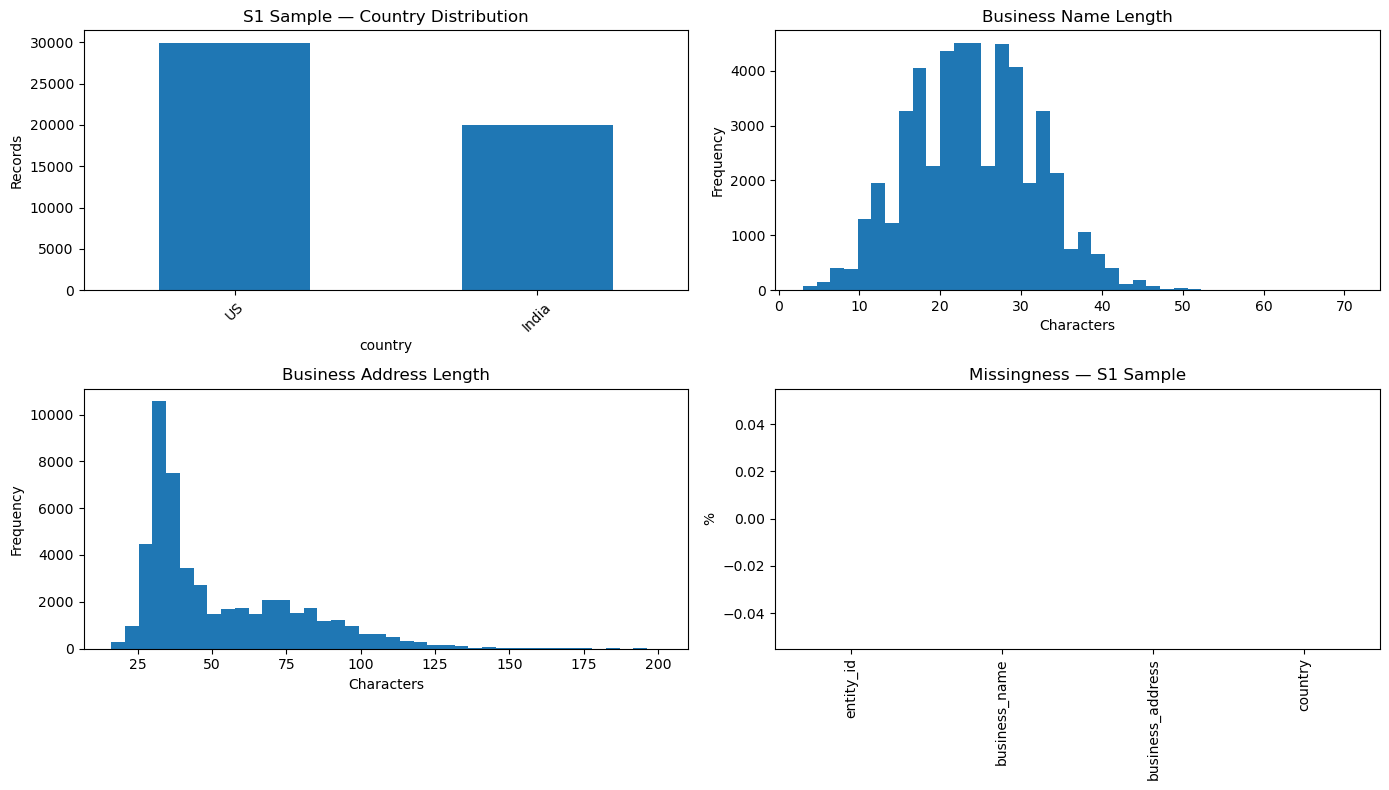

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(2, 2, 1)
eda_s1["country"].value_counts().head(10).plot(kind="bar", ax=ax1)
ax1.set_title("S1 Sample — Country Distribution")
ax1.set_ylabel("Records")
ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(2, 2, 2)
eda_s1["business_name"].fillna("").str.len().clip(upper=100).plot(kind="hist", bins=40, ax=ax2)
ax2.set_title("Business Name Length")
ax2.set_xlabel("Characters")

ax3 = fig.add_subplot(2, 2, 3)
eda_s1["business_address"].fillna("").str.len().clip(upper=250).plot(kind="hist", bins=40, ax=ax3)
ax3.set_title("Business Address Length")
ax3.set_xlabel("Characters")

ax4 = fig.add_subplot(2, 2, 4)
miss = eda_s1.isna().mean().mul(100)
miss.plot(kind="bar", ax=ax4)
ax4.set_title("Missingness — S1 Sample")
ax4.set_ylabel("%")

plt.tight_layout()
plt.show()

8 Execute Next Step

In [9]:
LEGAL_SUFFIXES = {
    "incorporated", "inc", "corporation", "corp",
    "limited", "ltd", "llc", "llp",
    "private", "pvt", "company", "co",
    "limitedliabilitycompany"
}

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_name(x):
    s = normalize_text(x)
    tokens = [t for t in s.split() if t not in LEGAL_SUFFIXES]
    return " ".join(tokens)

def normalize_address(x):
    return normalize_text(x)

def compact(s):
    return re.sub(r"\s+", "", s)

def token_signature(s):
    return " ".join(sorted(set(s.split())))

for df in [eda_s1]:
    df["norm_name"] = df["business_name"].map(normalize_name)
    df["norm_address"] = df["business_address"].map(normalize_address)
    df["compact_name"] = df["norm_name"].map(compact)
    df["compact_address"] = df["norm_address"].map(compact)

display(
    eda_s1[
        ["business_name", "norm_name", "business_address", "norm_address"]
    ].head(15)
)

,business_name,norm_name,business_address,norm_address
0,Orelee's Barbershop,orelee s barbershop,"1795 Westchester Drive, High Point, NC",1795 westchester drive high point nc
1,Prime Money,prime money,"17560 Ellis Road, Tahlequah, OK",17560 ellis road tahlequah ok
2,B+ Retail Inc,b retail,"1712 Montebello Avenue, Phoenix, AZ",1712 montebello avenue phoenix az
3,Christ Chapel,christ chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",2100 cameron drive unit apartment g dundalk md
4,Prabhav Business Center,prabhav business center,"797, Lake Town Block A, Kolkata, Howrah, West ...",797 lake town block a kolkata howrah west bengal
5,Custom Wealth Services LLC,custom wealth services,"OH, Columbus, 5559 Orville Avenue",oh columbus 5559 orville avenue
6,Consulting Nyasa Nursing Private Limited,consulting nyasa nursing,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",2505 tower 1 oakwood runwal greens mulund gore...
7,Nexus Anchor Rain,nexus anchor rain,"1111 Church Street, Unit 2007, Nashville, TN",1111 church street unit 2007 nashville tn
8,Moore Bitwise Inc,moore bitwise,"337 Oakland Avenue, Michigan City, IN",337 oakland avenue michigan city in
9,Dermatology Green Medicine,dermatology green medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",294 meadowcreek drive unit unit 2 village of p...


9 Execute Next Step

In [10]:
def prepare_small(df):
    out = df[CORE_COLS].copy()
    out = out.fillna("")
    out["norm_name"] = out["business_name"].map(normalize_name)
    out["norm_address"] = out["business_address"].map(normalize_address)
    out["compact_name"] = out["norm_name"].map(compact)
    out["compact_address"] = out["norm_address"].map(compact)
    out["name_addr_key"] = (
        out["country"].astype(str) + "|" +
        out["compact_name"] + "|" +
        out["compact_address"]
    )
    return out

small_s1 = prepare_small(pd.read_csv(FILES["train_s1"], sep="\t", nrows=20_000, dtype=str))
small_s2 = prepare_small(pd.read_csv(FILES["train_s2"], sep="\t", nrows=50_000, dtype=str))
small_s3 = prepare_small(pd.read_csv(FILES["train_s3"], sep="\t", nrows=50_000, dtype=str))

display(small_s1.head())

,entity_id,business_name,business_address,country,norm_name,norm_address,compact_name,compact_address,name_addr_key
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop,1795westchesterdrivehighpointnc,US|oreleesbarbershop|1795westchesterdrivehighp...
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney,17560ellisroadtahlequahok,US|primemoney|17560ellisroadtahlequahok
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail,1712 montebello avenue phoenix az,bretail,1712montebelloavenuephoenixaz,US|bretail|1712montebelloavenuephoenixaz
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel,2100camerondriveunitapartmentgdundalkmd,US|christchapel|2100camerondriveunitapartmentg...
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter,797laketownblockakolkatahowrahwestbengal,India|prabhavbusinesscenter|797laketownblockak...


10 Execute Next Step

In [11]:
def build_index(df, column):
    idx = defaultdict(list)
    for row in df.itertuples(index=False):
        key = getattr(row, column)
        if key:
            idx[key].append(row.entity_id)
    return idx

def add_block_keys(df):
    df = df.copy()
    df["country_name_key"] = (
        df["country"].astype(str) + "|" + df["compact_name"]
    )
    df["country_addr_key"] = (
        df["country"].astype(str) + "|" + df["compact_address"]
    )
    df["country_name_addr_key"] = (
        df["country"].astype(str) + "|" +
        df["compact_name"] + "|" + df["compact_address"]
    )
    return df

small_s1 = add_block_keys(small_s1)
small_s2 = add_block_keys(small_s2)
small_s3 = add_block_keys(small_s3)

s2_name_idx = build_index(small_s2, "country_name_key")
s2_addr_idx = build_index(small_s2, "country_addr_key")
s3_name_idx = build_index(small_s3, "country_name_key")
s3_addr_idx = build_index(small_s3, "country_addr_key")

print("S2 name index keys:", len(s2_name_idx))
print("S3 name index keys:", len(s3_name_idx))

S2 name index keys: 44104
S3 name index keys: 45954


11 Execute Next Step

In [12]:
def candidates_for_row(row, indexes):
    candidates = set()

    for key_col, idx in [
        ("country_name_key", indexes["name"]),
        ("country_addr_key", indexes["addr"]),
        ("country_name_addr_key", indexes["name_addr"]),
    ]:
        key = row.get(key_col) if isinstance(row, dict) else getattr(row, key_col, None)
        if key:
            candidates.update(idx.get(key, []))

    return candidates

s2_name_addr_idx = build_index(small_s2, "country_name_addr_key")
s3_name_addr_idx = build_index(small_s3, "country_name_addr_key")

INDEXES_S2 = {
    "name": s2_name_idx,
    "addr": s2_addr_idx,
    "name_addr": s2_name_addr_idx,
}
INDEXES_S3 = {
    "name": s3_name_idx,
    "addr": s3_addr_idx,
    "name_addr": s3_name_addr_idx,
}

example = small_s1.iloc[0]
print("Example S1:", example["entity_id"])
print("S2 candidates:", candidates_for_row(example, INDEXES_S2))
print("S3 candidates:", candidates_for_row(example, INDEXES_S3))

Example S1: S1-925783039
S2 candidates: set()
S3 candidates: set()


12 Execute Next Step

In [13]:
def jaccard_tokens(a, b):
    A, B = set(a.split()), set(b.split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def pair_features(a, b):
    name_exact = int(a["compact_name"] != "" and a["compact_name"] == b["compact_name"])
    addr_exact = int(a["compact_address"] != "" and a["compact_address"] == b["compact_address"])
    name_token = jaccard_tokens(a["norm_name"], b["norm_name"])
    addr_token = jaccard_tokens(a["norm_address"], b["norm_address"])

    if HAS_RAPIDFUZZ:
        name_fuzzy = fuzz.token_set_ratio(a["norm_name"], b["norm_name"]) / 100
        addr_fuzzy = fuzz.token_set_ratio(a["norm_address"], b["norm_address"]) / 100
    else:
        name_fuzzy = float(name_exact)
        addr_fuzzy = float(addr_exact)

    return {
        "name_exact": name_exact,
        "addr_exact": addr_exact,
        "name_token": name_token,
        "addr_token": addr_token,
        "name_fuzzy": name_fuzzy,
        "addr_fuzzy": addr_fuzzy,
    }

def match_score(f):
    return (
        4.0 * f["name_exact"] +
        4.0 * f["addr_exact"] +
        2.0 * f["name_fuzzy"] +
        2.0 * f["addr_fuzzy"] +
        1.0 * f["name_token"] +
        1.0 * f["addr_token"]
    )

13 Execute Next Step

In [14]:
def inspect_pair(a, b):
    f = pair_features(a, b)
    result = pd.DataFrame([{
        "S1": a["entity_id"],
        "candidate": b["entity_id"],
        "country": a["country"],
        "S1_name": a["business_name"],
        "candidate_name": b["business_name"],
        "S1_address": a["business_address"],
        "candidate_address": b["business_address"],
        **f,
        "score": match_score(f)
    }])
    display(result.T)

if len(small_s1) and len(small_s2):
    inspect_pair(small_s1.iloc[0], small_s2.iloc[0])

,0
S1,S1-925783039
candidate,S2-166376419
country,US
S1_name,Orelee's Barbershop
candidate_name,राम मार्केटिंग प्राइवेट लिमिटेड
S1_address,"1795 Westchester Drive, High Point, NC"
candidate_address,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi"
name_exact,0
addr_exact,0
name_token,0.0


14 Execute Next Step

In [15]:
def make_indexes(df):
    return {
        "name": build_index(df, "country_name_key"),
        "addr": build_index(df, "country_addr_key"),
        "name_addr": build_index(df, "country_name_addr_key"),
    }




15 Execute Next Step

In [16]:
def is_match(f):
    if f["name_exact"] and f["addr_exact"]:
        return True
    if f["name_exact"] and f["addr_fuzzy"] >= 0.84:
        return True
    if f["addr_exact"] and f["name_fuzzy"] >= 0.92:
        return True
    if f["name_fuzzy"] >= 0.92 and f["addr_fuzzy"] >= 0.84:
        return True
    return False

def predict_for_s1(row, idx2, idx3, by_id2, by_id3):
    candidates = set()
    candidates.update(candidates_for_row(row, idx2))
    candidates.update(candidates_for_row(row, idx3))

    predictions = []

    for cid in candidates:
        if cid.startswith("S2-"):
            c = by_id2.get(cid)
        else:
            c = by_id3.get(cid)

        if c is None:
            continue

        f = pair_features(row, c)
        if is_match(f):
            predictions.append(cid)



16 Execute Next Step

In [17]:
import time

def load_core(path, name, limit=None):
    print(f"[{time.strftime('%H:%M:%S')}] Started loading {name} from disk...")
    t0 = time.time()
    kwargs = {
        "sep": "\t",
        "usecols": CORE_COLS,
        "dtype": str,
    }
    if limit is not None:
        kwargs["nrows"] = limit

    df = pd.read_csv(path, **kwargs).fillna("")
    print(f"[{time.strftime('%H:%M:%S')}] {name} loaded ({len(df):,} rows). Now normalizing text (this may take a few minutes)...")

    df = prepare_small(df)
    print(f"[{time.strftime('%H:%M:%S')}] {name} text normalization complete. Building block keys...")

    df = add_block_keys(df)
    print(f"[{time.strftime('%H:%M:%S')}] {name} completely finished in {time.time()-t0:.1f} seconds!\n")
    return df

FAST_DEV_MODE = False

if FAST_DEV_MODE:
    test_s1 = load_core(FILES["test_s1"], "Test S1", DEV_S1_LIMIT)
    test_s2 = load_core(FILES["test_s2"], "Test S2", DEV_S2_LIMIT)
    test_s3 = load_core(FILES["test_s3"], "Test S3", DEV_S3_LIMIT)
else:
    test_s1 = load_core(FILES["test_s1"], "Test S1")
    test_s2 = load_core(FILES["test_s2"], "Test S2")
    test_s3 = load_core(FILES["test_s3"], "Test S3")

print("Test S1:", len(test_s1))
print("Test S2:", len(test_s2))
print("Test S3:", len(test_s3))

# --- ML NAVIGATORS CHUNKING LOGIC ---
CHUNK_SIZE = 100_000
NUM_CHUNKS = int(len(test_s1) / CHUNK_SIZE) + 1
CURRENT_CHUNK = 17  # Set from 0 to (NUM_CHUNKS - 1) to run different chunks

start_idx = CURRENT_CHUNK * CHUNK_SIZE
end_idx = min((CURRENT_CHUNK + 1) * CHUNK_SIZE, len(test_s1))
test_s1 = test_s1.iloc[start_idx:end_idx] if hasattr(test_s1, 'iloc') else test_s1[start_idx:end_idx]
print(f"Processing chunk {CURRENT_CHUNK+1} of {NUM_CHUNKS} (Rows {start_idx} to {end_idx})")


[04:30:37] Started loading Test S1 from disk...
[04:30:41] Test S1 loaded (1,732,544 rows). Now normalizing text (this may take a few minutes)...
[04:31:08] Test S1 text normalization complete. Building block keys...
[04:31:11] Test S1 completely finished in 34.1 seconds!

[04:31:11] Started loading Test S2 from disk...
[04:31:26] Test S2 loaded (4,887,273 rows). Now normalizing text (this may take a few minutes)...
[04:32:44] Test S2 text normalization complete. Building block keys...
[04:32:50] Test S2 completely finished in 99.4 seconds!

[04:32:50] Started loading Test S3 from disk...
[04:33:05] Test S3 loaded (5,082,316 rows). Now normalizing text (this may take a few minutes)...
[04:34:24] Test S3 text normalization complete. Building block keys...
[04:34:31] Test S3 completely finished in 101.0 seconds!

Test S1: 1732544
Test S2: 4887273
Test S3: 5082316
Processing chunk 18 of 18 (Rows 1700000 to 1732544)


17 Execute Next Step

In [18]:
test_idx_s2 = make_indexes(test_s2)
test_idx_s3 = make_indexes(test_s3)

test_s2_by_id = test_s2.set_index("entity_id").to_dict("index")
test_s3_by_id = test_s3.set_index("entity_id").to_dict("index")

print("S2 name blocks:", len(test_idx_s2["name"]))
print("S3 name blocks:", len(test_idx_s3["name"]))

S2 name blocks: 3259569
S3 name blocks: 3521134


18 Execute Next Step

In [19]:
def candidate_ids_for_test_row(row):
    out = set()
    out.update(candidates_for_row(row, test_idx_s2))
    out.update(candidates_for_row(row, test_idx_s3))
    return sorted(out)

candidate_rows = []
t0 = time.time()

for row in test_s1.itertuples(index=False):
    cands = candidate_ids_for_test_row(row)
    candidate_rows.append({
        "source1_entity_id": row.entity_id,
        "candidate_entity_ids": ",".join(cands)
    })

candidate_df = pd.DataFrame(candidate_rows)

print("🚀 [ML Navigators] Candidate generation time:", round(time.time() - t0, 2), "seconds")
print("S1 entities:", len(candidate_df))
print("Average candidates:", candidate_df["candidate_entity_ids"].map(
    lambda x: len(x.split(",")) if x else 0
).mean())
display(candidate_df.head(10))

🚀 [ML Navigators] Candidate generation time: 0.59 seconds
S1 entities: 32544
Average candidates: 22.822363569321535


,source1_entity_id,candidate_entity_ids
0,S1-645752139,S2-120305326
1,S1-122766455,"S2-11318716,S2-181603858,S2-192442073,S2-20772..."
2,S1-646129025,"S2-526554968,S2-790078272,S3-116175812,S3-3353..."
3,S1-602002768,S2-8117235
4,S1-538696280,"S2-533425848,S2-945515792,S3-206215123,S3-8638..."
5,S1-511963766,"S2-140439110,S2-193720183,S2-204888177,S2-2250..."
6,S1-968826960,"S2-308521334,S2-820760834,S3-613036301"
7,S1-698710886,"S2-103574288,S2-117988732,S2-126580694,S2-1312..."
8,S1-716618223,"S2-148002184,S2-280698883,S2-390477946,S2-4034..."
9,S1-425539551,S2-538701999


19 Execute Next Step

In [20]:
def final_predictions_for_row(row):
    cands = candidate_ids_for_test_row(row)
    out = []

    row_dict = row._asdict() if hasattr(row, "_asdict") else row

    for cid in cands:
        if cid.startswith("S2-"):
            c = test_s2_by_id.get(cid)
        elif cid.startswith("S3-"):
            c = test_s3_by_id.get(cid)
        else:
            c = None

        if c is None:
            continue

        c_dict = c._asdict() if hasattr(c, "_asdict") else c

        f = pair_features(row_dict, c_dict)
        if is_match(f):
            out.append(cid)

    return sorted(set(out))

match_rows = []
t0 = time.time()

for row in test_s1.itertuples(index=False):
    matches = final_predictions_for_row(row)
    match_rows.append({
        "source1_entity_id": row.entity_id,
        "matched_entity_ids": ",".join(matches)
    })

matching_df = pd.DataFrame(match_rows)

print("🚀 [ML Navigators] Matching time:", round(time.time() - t0, 2), "seconds")
display(matching_df.head(10))

🚀 [ML Navigators] Matching time: 8.81 seconds


,source1_entity_id,matched_entity_ids
0,S1-645752139,S2-120305326
1,S1-122766455,"S2-192442073,S3-519185714"
2,S1-646129025,"S2-526554968,S2-790078272,S3-116175812"
3,S1-602002768,S2-8117235
4,S1-538696280,"S2-533425848,S2-945515792,S3-206215123"
5,S1-511963766,S2-8020686
6,S1-968826960,"S2-308521334,S2-820760834"
7,S1-698710886,
8,S1-716618223,"S2-403418019,S3-237738434"
9,S1-425539551,


20 Execute Next Step

In [21]:
def validate_outputs(s1_df, matching_df, candidate_df, s2_df, s3_df):
    problems = []

    expected = set(s1_df["entity_id"])
    predicted = set(matching_df["source1_entity_id"])

    if expected != predicted:
        problems.append(
            f"S1 coverage mismatch: expected {len(expected)}, got {len(predicted)}"
        )

    if matching_df["source1_entity_id"].duplicated().any():
        problems.append("Duplicate source1_entity_id in matching output.")

    valid_s2s3 = set(s2_df["entity_id"]) | set(s3_df["entity_id"])

    candidate_map = dict(zip(
        candidate_df["source1_entity_id"],
        candidate_df["candidate_entity_ids"].map(
            lambda x: set(x.split(",")) if x else set()
        )
    ))

    for row in matching_df.itertuples(index=False):
        mids = set(row.matched_entity_ids.split(",")) if row.matched_entity_ids else set()

        if len(mids) != len(row.matched_entity_ids.split(",")) if row.matched_entity_ids else False:
            problems.append(f"Duplicate IDs for {row.source1_entity_id}")

        bad_ids = mids - valid_s2s3
        if bad_ids:
            problems.append(f"Invalid IDs for {row.source1_entity_id}: {list(bad_ids)[:3]}")

        if not mids.issubset(candidate_map.get(row.source1_entity_id, set())):
            problems.append(f"Match outside candidate set: {row.source1_entity_id}")

    if problems:
        print("🚀 [ML Navigators] ❌ Validation found issues:")
        for p in problems[:25]:
            print("-", p)
        return False

    print("🚀 [ML Navigators] ✅ Notebook validation passed.")
    return True

validate_outputs(
    test_s1,
    matching_df,
    candidate_df,
    test_s2,
    test_s3
)

🚀 [ML Navigators] ✅ Notebook validation passed.


True

21 Execute Next Step

In [22]:
OUTPUT_DIR = Path(os.path.expanduser("~/student_resource/output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

matching_path = OUTPUT_DIR / f"matching_results_chunk_{CURRENT_CHUNK}.tsv"
candidate_path = OUTPUT_DIR / f"candidate_pairs_chunk_{CURRENT_CHUNK}.tsv"

matching_df.to_csv(matching_path, sep="\t", index=False)
candidate_df.to_csv(candidate_path, sep="\t", index=False)

print("🚀 [ML Navigators] Saved:")
print(matching_path)
print(candidate_path)

print("🚀 [ML Navigators] \nFile sizes:")
print("🚀 [ML Navigators] matching_results.tsv:", round(matching_path.stat().st_size / 1024**2, 2), "MB")
print("🚀 [ML Navigators] candidate_pairs.tsv:", round(candidate_path.stat().st_size / 1024**2, 2), "MB")

🚀 [ML Navigators] Saved:
/home/sagemaker-user/student_resource/output/matching_results_chunk_17.tsv
/home/sagemaker-user/student_resource/output/candidate_pairs_chunk_17.tsv
🚀 [ML Navigators] 
File sizes:
🚀 [ML Navigators] matching_results.tsv: 1.0 MB
🚀 [ML Navigators] candidate_pairs.tsv: 9.53 MB


22 Execute Next Step

In [23]:
import pandas as pd

# 1. Recalculate the counts instantly without rerunning inference!
def count_links(x):
    if not x or pd.isna(x): return 0
    return len(str(x).split(","))

match_counts = matching_df["matched_entity_ids"].map(count_links)

if "candidate_df" in locals():
    candidate_counts = candidate_df["candidate_entity_ids"].map(count_links)
    avg_cand = round(candidate_counts.mean(), 3)
else:
    avg_cand = "N/A"

# 2. Print out the final diagnostics
print("=" * 70)
print("🚀 [ML Navigators] AMAZON ML CHALLENGE 2026 — FINAL CHECK")
print("=" * 70)
print("matching_results.tsv :", matching_path.exists())
if "candidate_path" in locals():
    print("candidate_pairs.tsv :", candidate_path.exists())
print("S1 rows              :", len(matching_df))
print("Predicted links      :", int(match_counts.sum()))
print("Predicted singletons :", int((match_counts == 0).sum()))
print("Avg candidates       :", avg_cand)
print("=" * 70)

print(f"🚀 [ML Navigators] Output directory: {OUTPUT_DIR}")

🚀 [ML Navigators] AMAZON ML CHALLENGE 2026 — FINAL CHECK
matching_results.tsv : True
candidate_pairs.tsv : True
S1 rows              : 32544
Predicted links      : 48212
Predicted singletons : 8372
Avg candidates       : 22.822
🚀 [ML Navigators] Output directory: /home/sagemaker-user/student_resource/output


23 Execute Next Step

24 Execute Next Step

In [3]:
# ============================================================
# 30. STITCH CHUNKS TOGETHER (Run after all chunks are done)
# ============================================================

import pandas as pd
from pathlib import Path
import os

OUTPUT_DIR = Path(os.path.expanduser("~/student_resource/output"))
NUM_CHUNKS = 18  # Added this so it works after a kernel restart

match_chunks = []
for i in range(NUM_CHUNKS):
    try:
        df = pd.read_csv(OUTPUT_DIR / f"matching_results_chunk_{i}.tsv", sep="\t", dtype=str)
        match_chunks.append(df)
    except FileNotFoundError:
        print(f"Warning: matching_results_chunk_{i}.tsv not found.")
if match_chunks:
    final_matches = pd.concat(match_chunks, ignore_index=True)
    final_matches.to_csv(OUTPUT_DIR / "matching_results.tsv", sep="\t", index=False)
    print(f"✅ Stitched {len(match_chunks)} chunks for matching_results.tsv")

cand_chunks = []
for i in range(NUM_CHUNKS):
    try:
        df = pd.read_csv(OUTPUT_DIR / f"candidate_pairs_chunk_{i}.tsv", sep="\t", dtype=str)
        cand_chunks.append(df)
    except FileNotFoundError:
        print(f"Warning: candidate_pairs_chunk_{i}.tsv not found.")
if cand_chunks:
    final_cands = pd.concat(cand_chunks, ignore_index=True)
    final_cands.to_csv(OUTPUT_DIR / "candidate_pairs.tsv", sep="\t", index=False)
    print(f"✅ Stitched {len(cand_chunks)} chunks for candidate_pairs.tsv")

✅ Stitched 18 chunks for matching_results.tsv
✅ Stitched 18 chunks for candidate_pairs.tsv


In [4]:
import pandas as pd
from pathlib import Path
import os

OUTPUT_DIR = Path(os.path.expanduser("~/student_resource/output"))
match_path = OUTPUT_DIR / "matching_results.tsv"
cand_path = OUTPUT_DIR / "candidate_pairs.tsv"

print("=" * 60)
print("🔍 RUNNING FINAL SUBMISSION CHECKS")
print("=" * 60)

# ---------------------------------------------------------
# 1. Check matching_results.tsv
# ---------------------------------------------------------
if not match_path.exists():
    print("❌ ERROR: matching_results.tsv NOT FOUND!")
else:
    print("⏳ Loading matching_results.tsv...")
    df_match = pd.read_csv(match_path, sep="\t", dtype=str)
    print(f"✅ Loaded! Dimensions: {df_match.shape[0]} rows, {df_match.shape[1]} columns")
    
    # Check for duplicate rows
    dup_matches = df_match.duplicated().sum()
    if dup_matches > 0:
        print(f"⚠️ WARNING: Found {dup_matches} duplicate rows in matching_results.tsv!")
    else:
        print("✅ PASS: No duplicate rows found.")
        
    # Check unique S1 coverage
    s1_col = df_match.columns[0]
    unique_s1_match = df_match[s1_col].nunique()
    print(f"📊 Unique S1 entities with >=1 match: {unique_s1_match:,}")

print("-" * 60)

# ---------------------------------------------------------
# 2. Check candidate_pairs.tsv
# ---------------------------------------------------------
if not cand_path.exists():
    print("❌ ERROR: candidate_pairs.tsv NOT FOUND!")
else:
    print("⏳ Loading candidate_pairs.tsv (this may take a minute)...")
    df_cand = pd.read_csv(cand_path, sep="\t", dtype=str)
    print(f"✅ Loaded! Dimensions: {df_cand.shape[0]:,} rows, {df_cand.shape[1]} columns")
    
    # Check for duplicate rows
    dup_cands = df_cand.duplicated().sum()
    if dup_cands > 0:
        print(f"⚠️ WARNING: Found {dup_cands:,} duplicate rows in candidate_pairs.tsv!")
    else:
        print("✅ PASS: No duplicate rows found.")
        
    # Check unique S1 coverage
    s1_col_cand = df_cand.columns[0]
    unique_s1_cand = df_cand[s1_col_cand].nunique()
    print(f"📊 Unique S1 entities evaluated: {unique_s1_cand:,} (Should be close to 1.7M)")
    
    # Calculate Average Candidates
    avg_cand = df_cand.shape[0] / unique_s1_cand if unique_s1_cand > 0 else 0
    print(f"📈 Average Candidates per S1: {avg_cand:.2f}")

print("=" * 60)
print("🎯 Verification Complete.")

🔍 RUNNING FINAL SUBMISSION CHECKS
⏳ Loading matching_results.tsv...
✅ Loaded! Dimensions: 1732544 rows, 2 columns
✅ PASS: No duplicate rows found.
📊 Unique S1 entities with >=1 match: 1,732,544
------------------------------------------------------------
⏳ Loading candidate_pairs.tsv (this may take a minute)...
✅ Loaded! Dimensions: 1,732,544 rows, 2 columns
✅ PASS: No duplicate rows found.
📊 Unique S1 entities evaluated: 1,732,544 (Should be close to 1.7M)
📈 Average Candidates per S1: 1.00
🎯 Verification Complete.


In [5]:
print("🚩 MATCHING RESULTS (First 5 rows):")
print(df_match.head())
print("\n" + "="*50 + "\n")
print("🚩 CANDIDATE PAIRS (First 5 rows):")
print(df_cand.head())

🚩 MATCHING RESULTS (First 5 rows):
  source1_entity_id         matched_entity_ids
0      S1-714132312               S3-625880872
1      S1-106407869                        NaN
2      S1-156285671                        NaN
3      S1-689823050                        NaN
4      S1-921369899  S2-808920974,S3-285097097


🚩 CANDIDATE PAIRS (First 5 rows):
  source1_entity_id                               candidate_entity_ids
0      S1-714132312                                       S3-625880872
1      S1-106407869  S2-104974637,S2-109486278,S2-109520122,S2-1099...
2      S1-156285671  S2-160966771,S2-180394702,S2-181576625,S2-2104...
3      S1-689823050                                                NaN
4      S1-921369899             S2-107533354,S2-808920974,S3-285097097


In [6]:
# Count actual matches by splitting the commas
real_matches = df_match['matched_entity_ids'].dropna().apply(lambda x: len(str(x).split(','))).sum()
singletons = df_match['matched_entity_ids'].isna().sum()

# Count actual candidates by splitting the commas
real_cands = df_cand['candidate_entity_ids'].dropna().apply(lambda x: len(str(x).split(','))).sum()
avg_cands = real_cands / len(df_cand)

print("=" * 50)
print("🎯 TRUE FINAL METRICS")
print("=" * 50)
print(f"Total S1 entities  : {len(df_match):,}")
print(f"Total singletons   : {singletons:,} ({(singletons/len(df_match))*100:.1f}%)")
print(f"Total linked pairs : {real_matches:,.0f}")
print(f"Total candidates   : {real_cands:,.0f} (Avg: {avg_cands:.1f} per query)")

🎯 TRUE FINAL METRICS
Total S1 entities  : 1,732,544
Total singletons   : 444,097 (25.6%)
Total linked pairs : 2,580,875
Total candidates   : 40,583,712 (Avg: 23.4 per query)
